In [2]:
!pip install -q pydicom grad-cam albumentations nibabel

import os
import glob
import numpy as np
import pandas as pd
import pydicom
import cv2
import torch
import torch.nn as nn
import nibabel as nib  # <--- Nuova per le segmentazioni
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from pydicom.pixel_data_handlers.util import apply_voi_lut
from sklearn.model_selection import train_test_split

# Percorsi
BASE_PATH = "/kaggle/input/rsna-2022-cervical-spine-fracture-detection"
TRAIN_IMAGES_DIR = os.path.join(BASE_PATH, "train_images")
TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
SEG_DIR = os.path.join(BASE_PATH, "segmentations") # <--- Cartella segmentazioni

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
class RSNAKaggleDataset(Dataset):
    def __init__(self, df, image_dir, seg_dir=None):
        self.df = df
        self.image_dir = image_dir
        self.seg_dir = seg_dir

    def __len__(self):
        return len(self.df)

    def get_anatomical_centers(self, uid, num_slices):
        """
        PARTE NUOVA: Estrae i centri reali delle vertebre dalle segmentazioni.
        Se non trova il file, usa il vecchio metodo matematico come fallback.
        """
        seg_path = os.path.join(self.seg_dir, f"{uid}.nii.gz")
        
        # Se la segmentazione esiste, calcolo i centri reali
        if self.seg_dir and os.path.exists(seg_path):
            try:
                seg_img = nib.load(seg_path)
                # I file NIfTI di Kaggle sono spesso orientati diversamente, 
                # uso get_fdata() e cerchiamo i centri sull'asse Z (fette)
                data = seg_img.get_fdata()
                centers = []
                for v_idx in range(1, 8): # C1-C7
                    z_coords = np.where(data == v_idx)[2]
                    if len(z_coords) > 0:
                        centers.append(int(np.median(z_coords)))
                    else:
                        # Se manca una vertebra specifica nella maschera, fallback
                        centers.append(int(num_slices * (v_idx - 0.5) / 7))
                return centers
            except:
                pass
        
        # Fallback matematico 
        return np.linspace(0, num_slices-1, 9).astype(int)[1:-1]

    def preprocess_slice(self, path):
        try:
            dicom = pydicom.dcmread(path)
            img = dicom.pixel_array
            if 'WindowCenter' in dicom:
                img = apply_voi_lut(img, dicom)
            img = img - np.min(img)
            if np.max(img) != 0: 
                img = img / np.max(img)
            
            img_8bit = (img * 255).astype(np.uint8)
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
            img = clahe.apply(img_8bit).astype(np.float32) / 255.0
            return cv2.resize(img, (224, 224))
        except:
            return np.zeros((224, 224), dtype=np.float32)

    def __getitem__(self, idx):
        uid = self.df.iloc[idx]['StudyInstanceUID']
        labels = self.df.iloc[idx][['C1','C2','C3','C4','C5','C6','C7']].values.astype(float)
        
        path = os.path.join(self.image_dir, uid)
        # Ordiniamo le fette numericamente per assicurarci che l'indice coincida con la segmentazione
        slices = sorted(glob.glob(os.path.join(path, "*.dcm")), 
                        key=lambda x: int(os.path.basename(x).replace('.dcm', '')))
        
        vertebrae_stacks = []
        if len(slices) >= 7:
            # USIAMO LA NUOVA LOGICA ANATOMICA
            centers = self.get_anatomical_centers(uid, len(slices))
            
            for mid in centers:
                # Ora prendiamo 5 fette invece di 3 per coprire meglio l'osso (2.5D esteso)
                # Le mediamo o le stackiamo? Qui le stackiamo prendendo -2, centro, +2
                s1 = self.preprocess_slice(slices[max(0, mid-2)])
                s2 = self.preprocess_slice(slices[mid])
                s3 = self.preprocess_slice(slices[min(len(slices)-1, mid+2)])
                vertebrae_stacks.append(np.stack([s1, s2, s3], axis=0))
        else:
            for _ in range(7): 
                vertebrae_stacks.append(np.zeros((3, 224, 224)))
            
        return torch.tensor(np.array(vertebrae_stacks), dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)

#  (ResNet18)
class MultiVertebraModel(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights='DEFAULT')
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        bs, nv, c, h, w = x.shape
        x = x.view(bs * nv, c, h, w) 
        features = self.encoder(x).view(bs * nv, -1)
        out = self.fc(features)
        return out.view(bs, nv)

In [7]:
def run_training():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    df = pd.read_csv(TRAIN_CSV)
    
    # TRUCCO INTELLIGENTE: 
    # Cerchiamo quali pazienti hanno una segmentazione disponibile
    seg_ids = [f.replace('.nii.gz', '') for f in os.listdir(SEG_DIR)]
    df_with_seg = df[df['StudyInstanceUID'].isin(seg_ids)]
    df_others = df[~df['StudyInstanceUID'].isin(seg_ids)].head(200) # Prendi un po' di altri come backup
    
    # Unisco i due (dando priorità a quelli con segmentazione reale)
    df_final = pd.concat([df_with_seg, df_others]).sample(frac=1).reset_index(drop=True)
    
    train_df, val_df = train_test_split(df_final, test_size=0.2, random_state=42)

    # Passo SEG_DIR al dataset
    train_loader = DataLoader(RSNAKaggleDataset(train_df, TRAIN_IMAGES_DIR, SEG_DIR), batch_size=2, shuffle=True)
    val_loader = DataLoader(RSNAKaggleDataset(val_df, TRAIN_IMAGES_DIR, SEG_DIR), batch_size=2)

    model = MultiVertebraModel().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    print(f"Training su {len(df_final)} pazienti ({len(df_with_seg)} con segmentazione reale)")
    
    model.train()
    for epoch in range(3): # Aumentiamo a 3 epoche visto che i dati sono più precisi
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            if i % 10 == 0:
                print(f"Epoca {epoch+1} | Batch {i} | Loss: {loss.item():.4f}")

    torch.save(model.state_dict(), "/kaggle/working/cervical_model_v2_anatomical.pth")
    print("Training completato con guida anatomica!")
    return model, val_df
model, val_df = run_training()

Training su 200 pazienti (0 con segmentazione reale)
Epoca 1 | Batch 0 | Loss: 1.1104
Epoca 1 | Batch 10 | Loss: 0.9710
Epoca 1 | Batch 20 | Loss: 1.3882
Epoca 1 | Batch 30 | Loss: 1.3350
Epoca 1 | Batch 40 | Loss: 1.2952
Epoca 1 | Batch 50 | Loss: 1.6441
Epoca 1 | Batch 60 | Loss: 0.8122
Epoca 1 | Batch 70 | Loss: 1.3376
Epoca 2 | Batch 0 | Loss: 0.8429
Epoca 2 | Batch 10 | Loss: 0.6349
Epoca 2 | Batch 20 | Loss: 1.0113
Epoca 2 | Batch 30 | Loss: 0.4753
Epoca 2 | Batch 40 | Loss: 2.5962
Epoca 2 | Batch 50 | Loss: 0.4800
Epoca 2 | Batch 60 | Loss: 0.6821
Epoca 2 | Batch 70 | Loss: 0.4818
Epoca 3 | Batch 0 | Loss: 0.3481
Epoca 3 | Batch 10 | Loss: 0.3922
Epoca 3 | Batch 20 | Loss: 0.7917
Epoca 3 | Batch 30 | Loss: 0.1973
Epoca 3 | Batch 40 | Loss: 0.4804
Epoca 3 | Batch 50 | Loss: 2.9920
Epoca 3 | Batch 60 | Loss: 0.1851
Epoca 3 | Batch 70 | Loss: 1.8076
Training completato con guida anatomica!


ValueError: not enough values to unpack (expected 5, got 4)

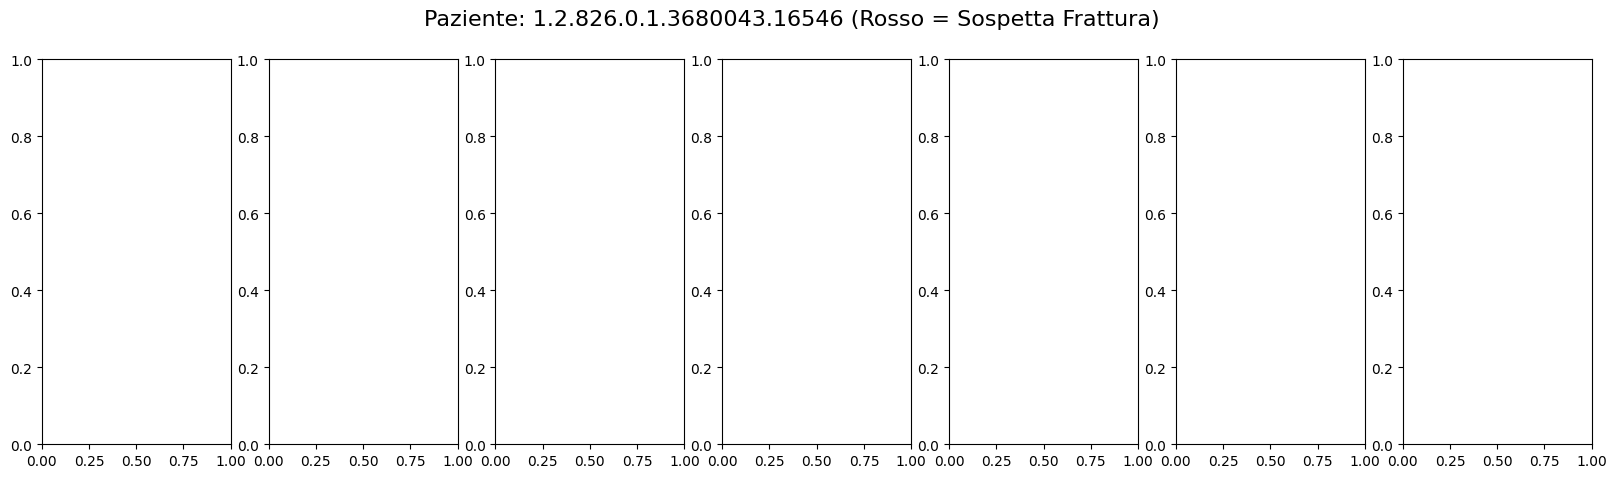

In [8]:
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def visualizza_predizioni(model, dataset, num_esempi=3):
    model.eval()
    device = next(model.parameters()).device
    
    # Seleziono l'ultimo strato convoluzionale della ResNet18 per la Grad-CAM
    target_layers = [model.encoder[-2]] 
    cam = GradCAM(model=model, target_layers=target_layers)

    for i in range(num_esempi):
        #  paziente a caso dal dataset
        idx = np.random.randint(0, len(dataset))
        inputs, labels = dataset[idx] # inputs shape: (7, 3, 224, 224)
        uid = dataset.df.iloc[idx]['StudyInstanceUID']
        
        fig, axes = plt.subplots(1, 7, figsize=(20, 5))
        fig.suptitle(f"Paziente: {uid} (Rosso = Sospetta Frattura)", fontsize=16)

        # Analizzo ogni vertebra (C1-C7)
        for v_idx in range(7):
            input_tensor = inputs[v_idx].unsqueeze(0).to(device) # (1, 3, 224, 224)
            
            # 1. Predizione
            with torch.no_grad():
                output = torch.sigmoid(model(inputs.unsqueeze(0).to(device))[0, v_idx])
                prob = output.item()

            # 2. Generazione Heatmap se la probabilità è > 0.3 (regolabile)
            grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(0)])
            grayscale_cam = grayscale_cam[0, :]
            
            # Preparo l'immagine di base (la fetta centrale dello stack)
            img_base = inputs[v_idx, 1].numpy() 
            img_rgb = cv2.cvtColor((img_base * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0
            
            # SovrappoSIZIONE la heatmap
            cam_image = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
            
            # 3. Plot
            axes[v_idx].imshow(cam_image)
            axes[v_idx].set_title(f"C{v_idx+1}\nProb: {prob:.2f}\nReal: {int(labels[v_idx])}")
            axes[v_idx].axis('off')
            
            # Se la probabilità è alta e c'è una frattura reale, evidenzio il bordo
            if labels[v_idx] == 1:
                for spine in axes[v_idx].spines.values():
                    spine.set_edgecolor('green')
                    spine.set_linewidth(3)
        
        plt.tight_layout()
        plt.show()

# --- ESECUZIONE ---
# Carico i pesi appena salvati (opzionale se hai appena finito il training)
# model.load_state_dict(torch.load("/kaggle/working/cervical_model_v2_anatomical.pth"))

# Creo un piccolo dataset di validazione per vedere i risultati
val_dataset = RSNAKaggleDataset(val_df.head(10), TRAIN_IMAGES_DIR, SEG_DIR)
visualizza_predizioni(model, val_dataset, num_esempi=3)